# Split the Dataset (Train/Test)

In [1]:
import pandas as pd
from sklearn.utils import shuffle

# Load preprocessed, normalized datasets, test set it the original one and train set is augmented.
df_test = pd.read_csv("../preprocessing/Augmented_rf/RF_raw/squat_dataset_test_original_normalized.csv")
df_train = pd.read_csv("../preprocessing/Augmented_rf/RF_raw/squat_dataset_train_augmented_and_original_normalized.csv")

#  Shuffle training data
df_train = shuffle(df_train, random_state=42).reset_index(drop=True)
df_test = shuffle(df_test, random_state=42).reset_index(drop=True)

feature_cols = [col for col in df_train.columns if col != "label"]

# Separate features and labels
X_train = df_train[feature_cols]
y_train = df_train["label"]

X_test = df_test[feature_cols]
y_test = df_test["label"]

print(f" Loaded features: {len(X_train)} training samples, {len(X_test)} test samples")
print(f" Using {len(feature_cols)} features")

 Loaded features: 880 training samples, 76 test samples
 Using 93 features


# Testing with original data import

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import pandas as pd

# Load full combined dataset
df = pd.read_csv("../preprocessing/ready/squat_dataset_3d_raw.csv")

# Shuffle entire dataset
df = shuffle(df, random_state=42).reset_index(drop=True)

# Split into features and labels
feature_cols = [col for col in df.columns if col != "label"]
X = df[feature_cols]
y = df["label"]

# Train/test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f" Loaded and split: {len(X_train)} training samples, {len(X_test)} test samples")
print(f" Using {len(feature_cols)} features: {feature_cols}")

 Loaded and split: 201 training samples, 51 test samples
 Using 120 features: ['left_hip_x_mean', 'left_hip_x_std', 'left_hip_x_min', 'left_hip_x_max', 'left_hip_y_mean', 'left_hip_y_std', 'left_hip_y_min', 'left_hip_y_max', 'left_hip_z_mean', 'left_hip_z_std', 'left_hip_z_min', 'left_hip_z_max', 'right_hip_x_mean', 'right_hip_x_std', 'right_hip_x_min', 'right_hip_x_max', 'right_hip_y_mean', 'right_hip_y_std', 'right_hip_y_min', 'right_hip_y_max', 'right_hip_z_mean', 'right_hip_z_std', 'right_hip_z_min', 'right_hip_z_max', 'left_knee_x_mean', 'left_knee_x_std', 'left_knee_x_min', 'left_knee_x_max', 'left_knee_y_mean', 'left_knee_y_std', 'left_knee_y_min', 'left_knee_y_max', 'left_knee_z_mean', 'left_knee_z_std', 'left_knee_z_min', 'left_knee_z_max', 'right_knee_x_mean', 'right_knee_x_std', 'right_knee_x_min', 'right_knee_x_max', 'right_knee_y_mean', 'right_knee_y_std', 'right_knee_y_min', 'right_knee_y_max', 'right_knee_z_mean', 'right_knee_z_std', 'right_knee_z_min', 'right_knee_z_max

# Nested Cross-Validation with Best Parameters Logging

In [3]:
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import math

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [
        int(math.sqrt(X_train.shape[1])),
        int(2 * math.sqrt(X_train.shape[1])),
        int(3 * math.sqrt(X_train.shape[1])),
        None
    ],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Initialize the base model, hitchhikers guide to the galaxy reference.
rf = RandomForestClassifier(random_state=42)

# Outer loop: Stratified K-Fold for evaluation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores and best parameters
cv_scores = []
best_params_list = []

# Perform nested cross-validation manually
for train_idx, val_idx in cv_outer.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Inner loop: Grid Search CV
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train_fold, y_train_fold)

    # Get best model and evaluate on validation set
    best_model = grid_search.best_estimator_
    val_score = best_model.score(X_val_fold, y_val_fold)

    # Store results
    cv_scores.append(val_score)
    best_params_list.append(grid_search.best_params_)

    print(f" Fold {len(cv_scores)} - Best Params: {grid_search.best_params_} - Validation Accuracy: {val_score:.4f}")

# Print final results
print(f"\n Nested CV Accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
print(" Best parameters from each fold:")
for i, params in enumerate(best_params_list, 1):
    print(f"  Fold {i}: {params}")
print(f"\n Best overall parameters: {grid_search.best_params_}")

 Fold 1 - Best Params: {'bootstrap': True, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} - Validation Accuracy: 1.0000
 Fold 2 - Best Params: {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100} - Validation Accuracy: 0.9500
 Fold 3 - Best Params: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300} - Validation Accuracy: 0.9500
 Fold 4 - Best Params: {'bootstrap': True, 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} - Validation Accuracy: 1.0000
 Fold 5 - Best Params: {'bootstrap': False, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100} - Validation Accuracy: 0.9750

 Nested CV Accuracy: 0.9750 ± 0.0224
 Best parameters from each fold:
  Fold 1: {'bootst

In [4]:
from collections import Counter

param_counts = Counter(tuple(sorted(params.items())) for params in best_params_list)
most_common_params = dict(param_counts.most_common(1)[0][0])

print("📌 Most consistent best parameters across folds:", most_common_params)

📌 Most consistent best parameters across folds: {'bootstrap': True, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


# Train the Final Model

In [5]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# Train the model
best_rf = RandomForestClassifier(**most_common_params, random_state=42)
best_rf.fit(X_train, y_train)

# save the trained model
# joblib.dump(best_rf, "preprocessing/trained_rf_model.pkl")

print("✅ Model trained and feature order saved!")

✅ Model trained and feature order saved!


#  Evaluate the Model

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f" ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.96      0.88      0.92        26
           1       0.89      0.96      0.92        25

    accuracy                           0.92        51
   macro avg       0.92      0.92      0.92        51
weighted avg       0.92      0.92      0.92        51

Confusion Matrix:
 [[23  3]
 [ 1 24]]
 ROC-AUC Score: 0.9838


# ROC curve

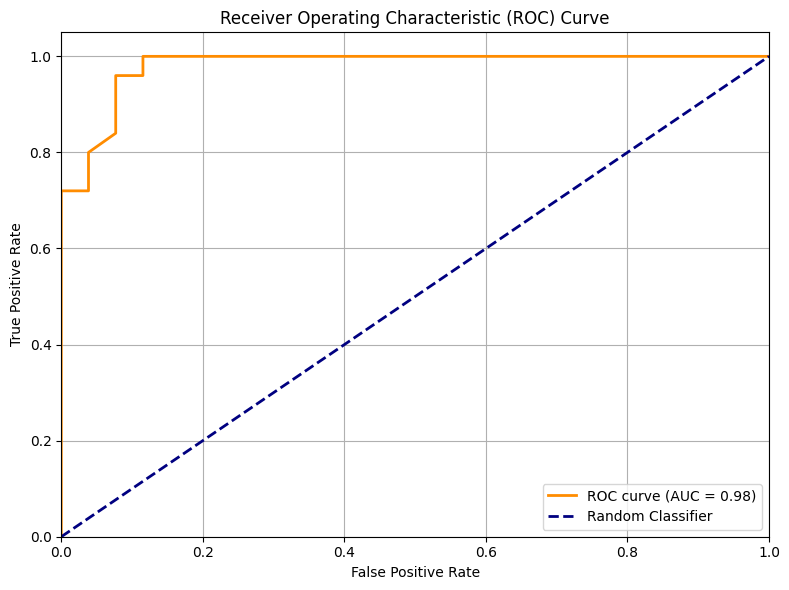

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class (good squats = 1)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Calculate false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Calculate AUC score
roc_auc = roc_auc_score(y_test, y_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


# Interpretability: Feature Importance

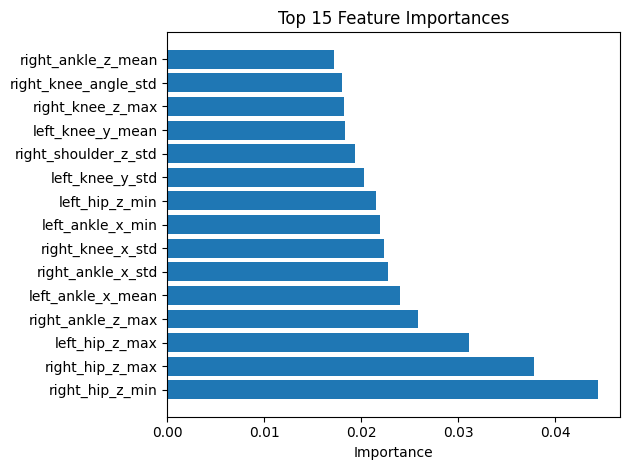

In [8]:
import matplotlib.pyplot as plt
importances = best_model.feature_importances_
feature_names = X_train.columns
sorted_idx = importances.argsort()[::-1]

plt.barh(feature_names[sorted_idx][:15], importances[sorted_idx][:15])
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
